In [3]:
!pip install -r ~/EC331-Thesis-Data/requirements.txt

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... one
  Using cached matplotlib-3.10.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached plotly-5.24.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached dash-2.18.2-py3-none-any.whl.metadata (10 kB)
  Using cached dash_bootstrap_components-1.7.1-py3-none-any.whl.metadata (17 kB)
  Using cached scipy-1.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached statsmodels-0.14.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.2 kB)
  Using cached pyarrow-19.0.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached nemosis-3.7.0-py3-none-any.whl.metadata (697 bytes)
  Using cached contourpy-1.3.1-cp3

In [3]:
!pip uninstall -y pyarrow
!pip install pyarrow==14.0.1

  Using cached pyarrow-14.0.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
Using cached pyarrow-14.0.1-cp312-cp312-manylinux_2_28_x86_64.whl (38.0 MB)


In [13]:
import pandas as pd
import boto3
import io

# S3 bucket and file information
bucket_name = 'thesis--ec331-s3'
file_key = 'Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202408010000.feather'

# Initialize S3 client
s3_client = boto3.client('s3')

try:
    # Method 1: Download directly to a temporary file and read
    print("Loading feather file from S3...")
    
    # Get the object from S3
    response = s3_client.get_object(Bucket=bucket_name, Key=file_key)
    
    # Read the feather file using pandas
    df = pd.read_feather(io.BytesIO(response['Body'].read()))
    
    # Display general information about the DataFrame
    print("\nDataFrame Info:")
    df.info()
    
    # Show the first few rows of the DataFrame
    print("\nDataFrame Head:")
    print(df.head())
    
    # Show the last few rows of the DataFrame
    print("\nDataFrame Tail:")
    print(df.tail())
    
    # Display descriptive statistics for numerical columns
    print("\nDataFrame Description:")
    print(df.describe(include='all'))
    
    # List all column names
    print("\nDataFrame Columns:")
    print(df.columns.tolist())
    
    # Get the shape of the DataFrame
    print("\nDataFrame Shape:")
    print(df.shape)
    
    # Check for missing values
    print("\nMissing Values:")
    print(df.isnull().sum())
    
except Exception as e:
    print(f"Error: {e}")

Loading feather file from S3...

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44641 entries, 0 to 44640
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   I               44641 non-null  object 
 1   TRADING         44641 non-null  object 
 2   PRICE           44641 non-null  object 
 3   3               44640 non-null  float64
 4   SETTLEMENTDATE  44640 non-null  object 
 5   RUNNO           44640 non-null  float64
 6   REGIONID        44640 non-null  object 
 7   PERIODID        44640 non-null  float64
 8   RRP             44640 non-null  float64
 9   EEP             44640 non-null  float64
 10  INVALIDFLAG     44640 non-null  float64
 11  LASTCHANGED     44640 non-null  object 
 12  ROP             44640 non-null  float64
 13  RAISE6SECRRP    44640 non-null  float64
 14  RAISE6SECROP    44640 non-null  float64
 15  RAISE60SECRRP   44640 non-null  float64
 16  RAISE60SECROP   44640 non-n

Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202408010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202409010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202410010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202411010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202412010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202310010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202311010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202312010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202401010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202402010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202403010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202404010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202405010000.feather
Processing Trading-price/PUBLIC_DVD

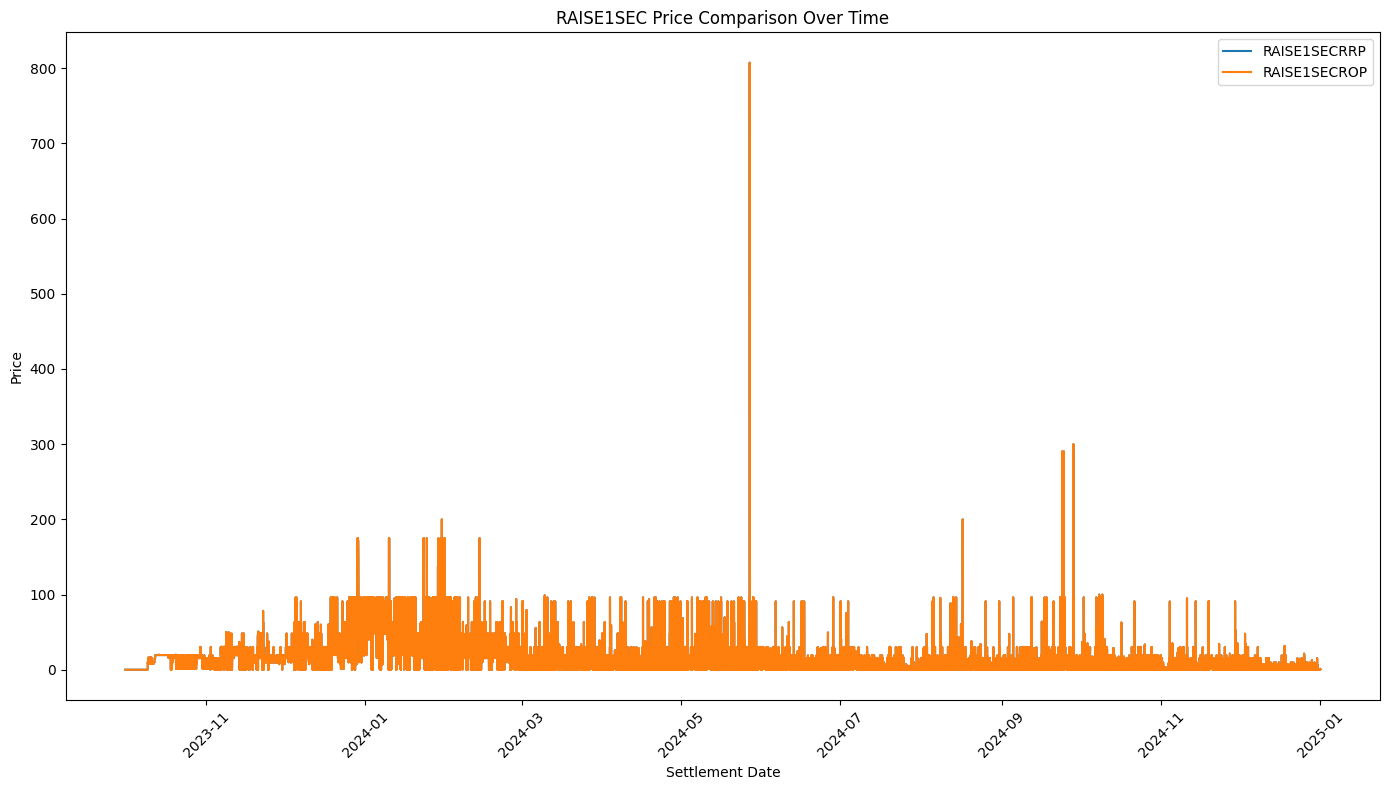

In [14]:
import boto3
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
from io import BytesIO

# Set up S3 connection
s3 = boto3.client('s3')
bucket_name = 'thesis--ec331-s3'
prefix = 'Trading-price/'

# List all objects in the bucket with the given prefix
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

# Initialize an empty dataframe to store all data
all_data = pd.DataFrame()

# Loop through each object and read it as a feather file
for obj in response.get('Contents', []):
    # Get the object
    file_key = obj['Key']
    
    # Only process feather files
    if file_key.endswith('.feather'):
        print(f"Processing {file_key}")
        
        # Download the file to memory
        response = s3.get_object(Bucket=bucket_name, Key=file_key)
        file_content = response['Body'].read()
        
        # Convert to BytesIO object and read with pyarrow
        bytes_buffer = BytesIO(file_content)
        df = feather.read_feather(bytes_buffer)
        
        # Append to the main dataframe
        all_data = pd.concat([all_data, df], ignore_index=True)

# Now you have all data in the all_data DataFrame
print(f"Total rows: {len(all_data)}")

# Convert SETTLEMENTDATE to datetime
all_data['SETTLEMENTDATE'] = pd.to_datetime(all_data['SETTLEMENTDATE'])

# Convert the columns to numeric
all_data['RAISE1SECRRP'] = pd.to_numeric(all_data['RAISE1SECRRP'], errors='coerce')
all_data['RAISE1SECROP'] = pd.to_numeric(all_data['RAISE1SECROP'], errors='coerce')

# Sort by date for proper time series plotting
all_data = all_data.sort_values('SETTLEMENTDATE')

# Basic plotting with SETTLEMENTDATE on x-axis
plt.figure(figsize=(14, 8))
plt.plot(all_data['SETTLEMENTDATE'], all_data['RAISE1SECRRP'], label='RAISE1SECRRP')
plt.plot(all_data['SETTLEMENTDATE'], all_data['RAISE1SECROP'], label='RAISE1SECROP')
plt.legend()
plt.title('RAISE1SEC Price Comparison Over Time')
plt.xlabel('Settlement Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('raise1sec_comparison_by_date.png')
plt.show()

Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202408010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202409010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202410010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202411010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202412010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202310010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202311010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202312010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202401010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202402010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202403010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202404010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202405010000.feather
Processing Trading-price/PUBLIC_DVD

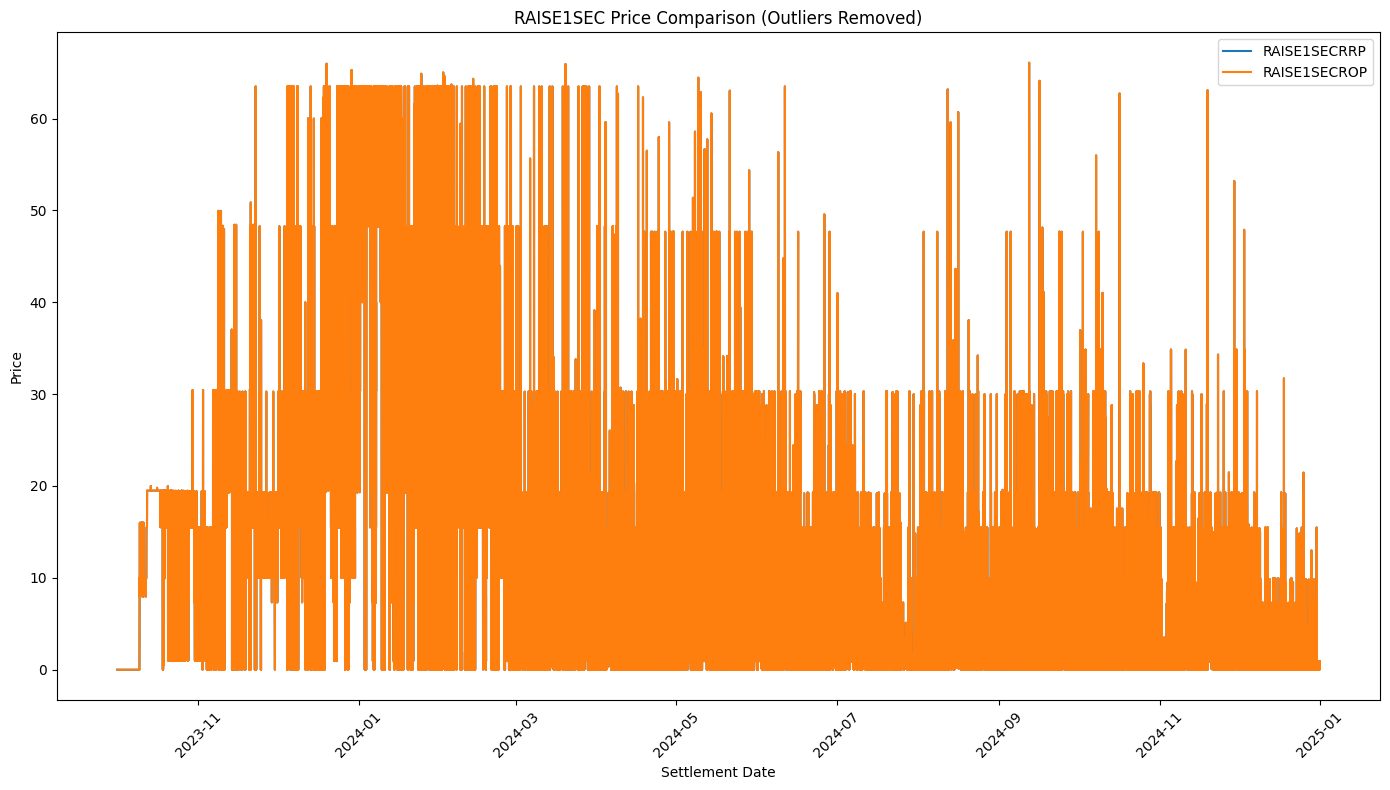

In [15]:
import boto3
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
from io import BytesIO

# Set up S3 connection
s3 = boto3.client('s3')
bucket_name = 'thesis--ec331-s3'
prefix = 'Trading-price/'

# List all objects in the bucket with the given prefix
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

# Initialize an empty dataframe to store all data
all_data = pd.DataFrame()

# Loop through each object and read it as a feather file
for obj in response.get('Contents', []):
    # Get the object
    file_key = obj['Key']
    
    # Only process feather files
    if file_key.endswith('.feather'):
        print(f"Processing {file_key}")
        
        # Download the file to memory
        response = s3.get_object(Bucket=bucket_name, Key=file_key)
        file_content = response['Body'].read()
        
        # Convert to BytesIO object and read with pyarrow
        bytes_buffer = BytesIO(file_content)
        df = feather.read_feather(bytes_buffer)
        
        # Append to the main dataframe
        all_data = pd.concat([all_data, df], ignore_index=True)

# Now you have all data in the all_data DataFrame
print(f"Total rows: {len(all_data)}")

# Convert SETTLEMENTDATE to datetime
all_data['SETTLEMENTDATE'] = pd.to_datetime(all_data['SETTLEMENTDATE'])

# Convert the columns to numeric
all_data['RAISE1SECRRP'] = pd.to_numeric(all_data['RAISE1SECRRP'], errors='coerce')
all_data['RAISE1SECROP'] = pd.to_numeric(all_data['RAISE1SECROP'], errors='coerce')

# Sort by date for proper time series plotting
all_data = all_data.sort_values('SETTLEMENTDATE')

# Basic plotting with SETTLEMENTDATE on x-axis
# Filter out extreme values (e.g., values > 3 standard deviations)
mean = all_data['RAISE1SECROP'].mean()
std = all_data['RAISE1SECROP'].std()
filtered_data = all_data[all_data['RAISE1SECROP'] <= mean + 3*std]

# Then plot with filtered data
plt.figure(figsize=(14, 8))
plt.plot(filtered_data['SETTLEMENTDATE'], filtered_data['RAISE1SECRRP'], label='RAISE1SECRRP')
plt.plot(filtered_data['SETTLEMENTDATE'], filtered_data['RAISE1SECROP'], label='RAISE1SECROP')
plt.legend()
plt.title('RAISE1SEC Price Comparison (Outliers Removed)')
plt.xlabel('Settlement Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202408010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202409010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202410010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202411010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202412010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202310010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202311010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202312010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202401010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202402010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202403010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202404010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202405010000.feather
Processing Trading-price/PUBLIC_DVD

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

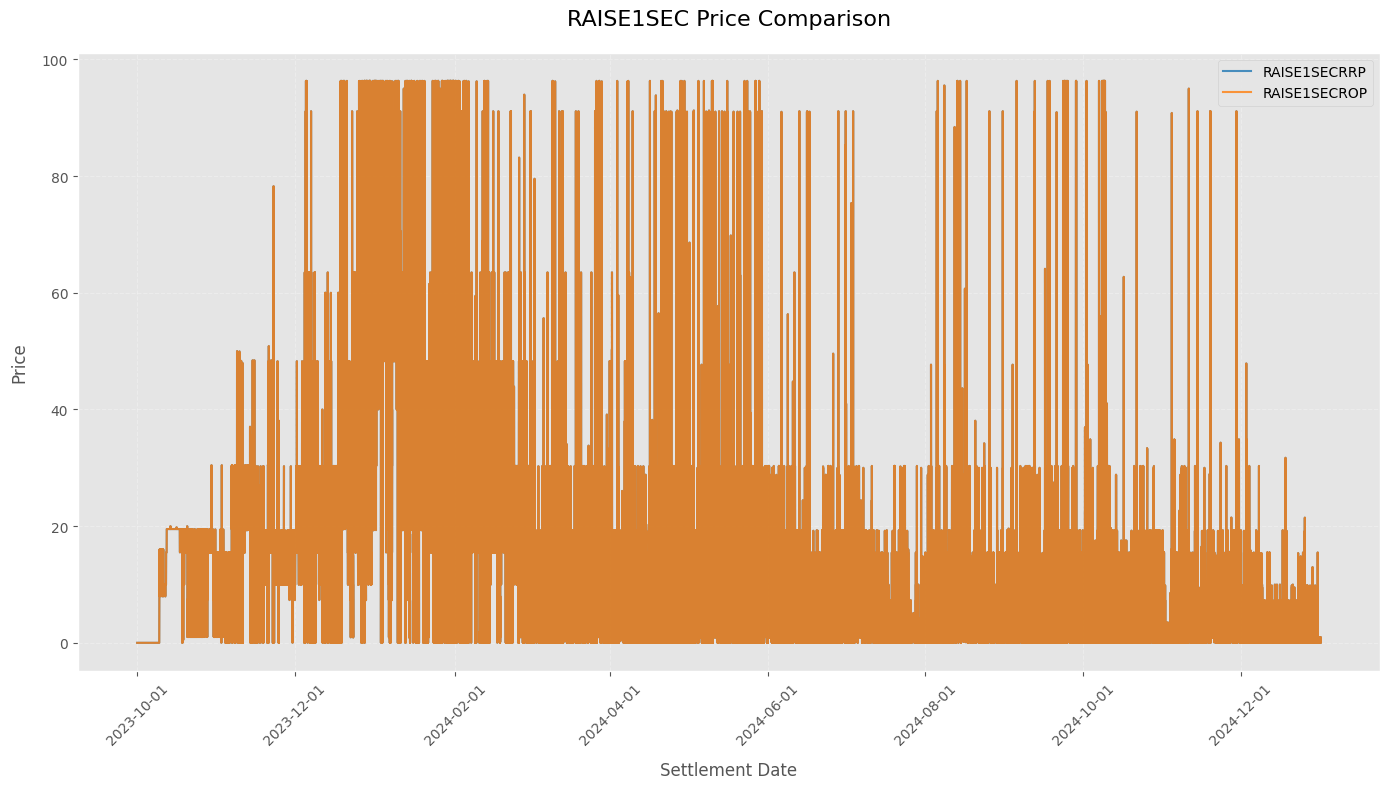

In [17]:
import boto3
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import BytesIO

# Set styling for better visuals using just matplotlib
plt.style.use('ggplot')  # A clean built-in style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# S3 connection code remains the same
s3 = boto3.client('s3')
bucket_name = 'thesis--ec331-s3'
prefix = 'Trading-price/'
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
all_data = pd.DataFrame()

# Loop through files (same as before)
for obj in response.get('Contents', []):
    file_key = obj['Key']
    if file_key.endswith('.feather'):
        print(f"Processing {file_key}")
        response = s3.get_object(Bucket=bucket_name, Key=file_key)
        file_content = response['Body'].read()
        bytes_buffer = BytesIO(file_content)
        df = feather.read_feather(bytes_buffer)
        all_data = pd.concat([all_data, df], ignore_index=True)

print(f"Total rows: {len(all_data)}")

# Data preprocessing
all_data['SETTLEMENTDATE'] = pd.to_datetime(all_data['SETTLEMENTDATE'])
all_data['RAISE1SECRRP'] = pd.to_numeric(all_data['RAISE1SECRRP'], errors='coerce')
all_data['RAISE1SECROP'] = pd.to_numeric(all_data['RAISE1SECROP'], errors='coerce')

# Sort by date
all_data = all_data.sort_values('SETTLEMENTDATE')

# More sophisticated outlier removal (using quantiles instead of standard deviations), i.e. winowing
q_low_rrp = all_data['RAISE1SECRRP'].quantile(0.01)
q_high_rrp = all_data['RAISE1SECRRP'].quantile(0.99)
q_low_rop = all_data['RAISE1SECROP'].quantile(0.01)
q_high_rop = all_data['RAISE1SECROP'].quantile(0.99)

filtered_data = all_data[(all_data['RAISE1SECRRP'] >= q_low_rrp) & 
                         (all_data['RAISE1SECRRP'] <= q_high_rrp) &
                         (all_data['RAISE1SECROP'] >= q_low_rop) & 
                         (all_data['RAISE1SECROP'] <= q_high_rop)]

# Create a cleaner plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot with improved styling
ax.plot(filtered_data['SETTLEMENTDATE'], filtered_data['RAISE1SECRRP'], 
        label='RAISE1SECRRP', linewidth=1.5, color='#1f77b4', alpha=0.8)
ax.plot(filtered_data['SETTLEMENTDATE'], filtered_data['RAISE1SECROP'], 
        label='RAISE1SECROP', linewidth=1.5, color='#ff7f0e', alpha=0.8)

# Improve x-axis date formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Enhance the overall look
ax.set_title('RAISE1SEC Price Comparison', fontsize=16, pad=20)
ax.set_xlabel('Settlement Date', fontsize=12, labelpad=10)
ax.set_ylabel('Price', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=45)

# Enhance legend
ax.legend(frameon=True, loc='upper right')

# Optional: if you want to smooth the line, you can add:
# - Downsampling by day (uncomment below)
# filtered_data = filtered_data.set_index('SETTLEMENTDATE').resample('D').mean().reset_index()

plt.tight_layout()
plt.savefig('raise1sec_price_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202408010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202409010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202410010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202411010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202412010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202310010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202311010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202312010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202401010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202402010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202403010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202404010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202405010000.feather
Processing Trading-price/PUBLIC_DVD

/tmp/ipykernel_3912/1241811608.py:54: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  daily_data = filtered_data.set_index('SETTLEMENTDATE').resample('D').mean().reset_index()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
fin

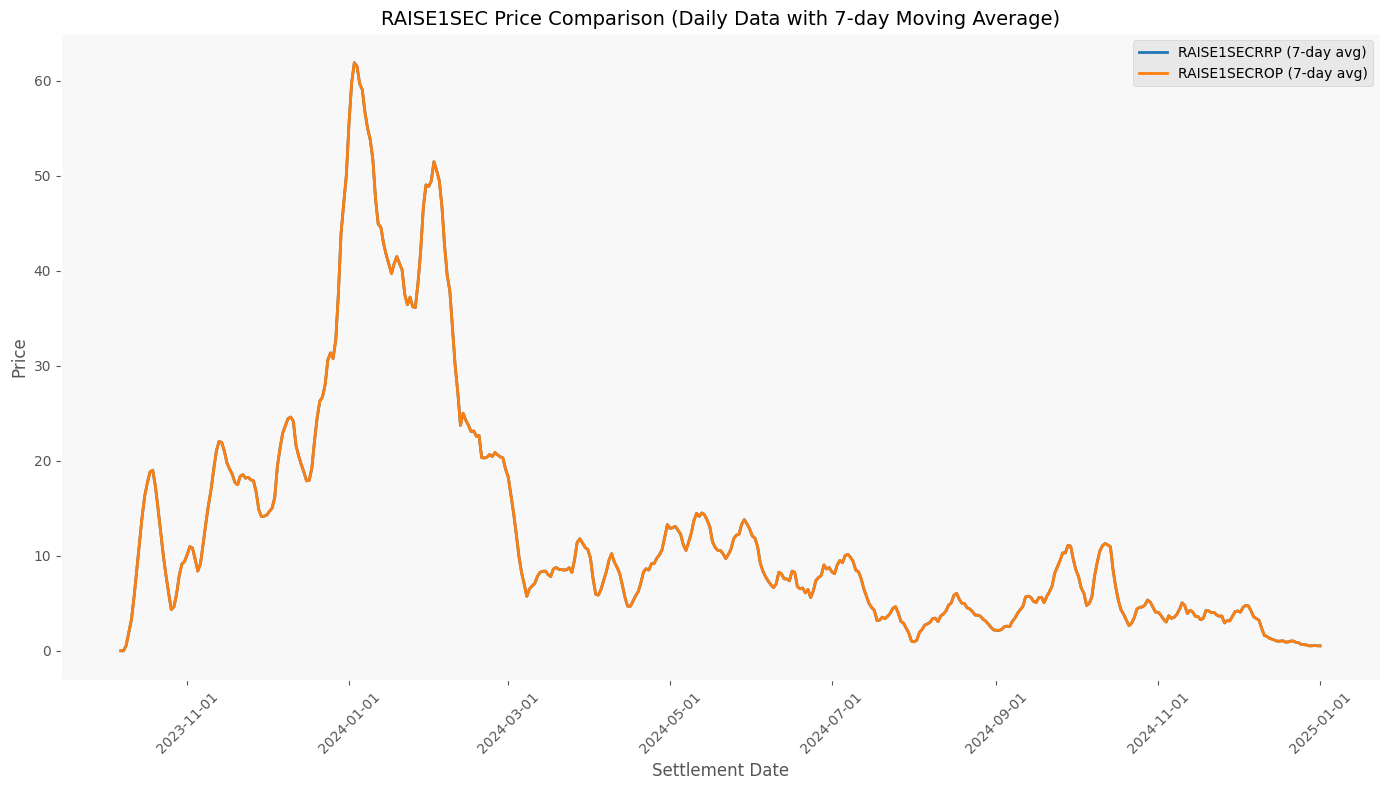

In [18]:
import boto3
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import BytesIO

# Set styling for better visuals
plt.style.use('ggplot')  # A clean built-in style
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# S3 connection code remains the same
s3 = boto3.client('s3')
bucket_name = 'thesis--ec331-s3'
prefix = 'Trading-price/'
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
all_data = pd.DataFrame()

# Loop through files
for obj in response.get('Contents', []):
    file_key = obj['Key']
    if file_key.endswith('.feather'):
        print(f"Processing {file_key}")
        response = s3.get_object(Bucket=bucket_name, Key=file_key)
        file_content = response['Body'].read()
        bytes_buffer = BytesIO(file_content)
        df = feather.read_feather(bytes_buffer)
        all_data = pd.concat([all_data, df], ignore_index=True)

print(f"Total rows: {len(all_data)}")

# Data preprocessing
all_data['SETTLEMENTDATE'] = pd.to_datetime(all_data['SETTLEMENTDATE'])
all_data['RAISE1SECRRP'] = pd.to_numeric(all_data['RAISE1SECRRP'], errors='coerce')
all_data['RAISE1SECROP'] = pd.to_numeric(all_data['RAISE1SECROP'], errors='coerce')

# Sort by date
all_data = all_data.sort_values('SETTLEMENTDATE')

# Outlier removal using quantiles
q_low_rrp = all_data['RAISE1SECRRP'].quantile(0.01)
q_high_rrp = all_data['RAISE1SECRRP'].quantile(0.99)
q_low_rop = all_data['RAISE1SECROP'].quantile(0.01)
q_high_rop = all_data['RAISE1SECROP'].quantile(0.99)

filtered_data = all_data[(all_data['RAISE1SECRRP'] >= q_low_rrp) & 
                         (all_data['RAISE1SECRRP'] <= q_high_rrp) &
                         (all_data['RAISE1SECROP'] >= q_low_rop) & 
                         (all_data['RAISE1SECROP'] <= q_high_rop)]

# STEP 1: Resample to daily data
daily_data = filtered_data.set_index('SETTLEMENTDATE').resample('D').mean().reset_index()

# STEP 2: Apply a 7-day moving average for additional smoothing
daily_data['RAISE1SECRRP_SMOOTH'] = daily_data['RAISE1SECRRP'].rolling(window=7).mean()
daily_data['RAISE1SECROP_SMOOTH'] = daily_data['RAISE1SECROP'].rolling(window=7).mean()
daily_data = daily_data.dropna(subset=['RAISE1SECRRP_SMOOTH', 'RAISE1SECROP_SMOOTH'])

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the smoothed data
ax.plot(daily_data['SETTLEMENTDATE'], daily_data['RAISE1SECRRP_SMOOTH'], 
        label='RAISE1SECRRP (7-day avg)', linewidth=2, color='#1f77b4')
ax.plot(daily_data['SETTLEMENTDATE'], daily_data['RAISE1SECROP_SMOOTH'], 
        label='RAISE1SECROP (7-day avg)', linewidth=2, color='#ff7f0e')

# Format the x-axis to show dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Enhance the overall look
ax.set_title('RAISE1SEC Price Comparison (Daily Data with 7-day Moving Average)', fontsize=14)
ax.set_xlabel('Settlement Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Enhance legend
ax.legend(frameon=True, loc='upper right')

# Add a light background color to make the plot stand out
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('raise1sec_price_comparison_smooth.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# Set figure size
plt.figure(figsize=(12, 6))

# Plot the average Raise and Lower Regulation FCAS prices
plt.plot(df['Quarter'], df['AVG_RAISEREG ($ per megawatt)'], label="Avg Raise Regulation", linestyle='-', marker='o', markersize=5)
plt.plot(df['Quarter'], df['AVG_LOWERREG ($ per megawatt)'], label="Avg Lower Regulation", linestyle='-', marker='x', markersize=5)

# Formatting the plot
plt.xlabel("Year-Quarter")
plt.ylabel("Price ($ per MW)")
plt.title("Quarterly Average of Raise & Lower Regulation FCAS Prices from 2010 Q1 - 2024 Q3")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
# Get the price bids.
price_data = dynamic_data_compiler(start_time='2010/01/19 00:00:00',
                                   end_time='2024/09/01 00:00:00',
                                   table_name='DISPATCHPRICE',
                                   raw_data_location=raw_data_cache,
                                   rebuild=True)

In [ ]:
price_data

In [ ]:
price_data.describe()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the 'SETTLEMENTDATE' column is in datetime format
price_data['SETTLEMENTDATE'] = pd.to_datetime(price_data['SETTLEMENTDATE'])

# Resample the data to monthly averages for better visualization
df_resampled = price_data.set_index('SETTLEMENTDATE').resample('M').mean()

# Set figure size
plt.figure(figsize=(14, 7))

# Plot each FCAS category over time
plt.plot(df_resampled.index, df_resampled['RRP'], label="Regional Reference Price (RRP)", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['RAISE6SECRRP'], label="Raise 6-Sec", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['RAISE60SECRRP'], label="Raise 60-Sec", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['RAISE5MINRRP'], label="Raise 5-Min", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['RAISEREGRRP'], label="Raise Regulation", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['LOWER6SECRRP'], label="Lower 6-Sec", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['LOWER60SECRRP'], label="Lower 60-Sec", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['LOWER5MINRRP'], label="Lower 5-Min", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['LOWERREGRRP'], label="Lower Regulation", linestyle='-', marker='.')

# Formatting the plot
plt.xlabel("Time (Months)")
plt.ylabel("Price ($ per MW)")
plt.title("FCAS Prices Over Time (Resampled Monthly)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the 'SETTLEMENTDATE' column is in datetime format
price_data['SETTLEMENTDATE'] = pd.to_datetime(price_data['SETTLEMENTDATE'])

# Resample the data to monthly averages for better visualization
df_resampled = price_data.set_index('SETTLEMENTDATE').resample('M').mean()

# Set figure size
plt.figure(figsize=(14, 7))

# Plot each FCAS category over time
plt.plot(df_resampled.index, df_resampled['RAISEREGRRP'], label="Raise Regulation", linestyle='-', marker='.')
plt.plot(df_resampled.index, df_resampled['LOWERREGRRP'], label="Lower Regulation", linestyle='-', marker='.')

# Formatting the plot
plt.xlabel("Time (Months)")
plt.ylabel("Price ($ per MW)")
plt.title("FCAS Prices Over Time (Resampled Monthly)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Is there a simple way to calculate payments for 
If it's roughly based on marginal cost pricing, even if there are often more complicated factors, and it's completely orthogonal to standard energy dispatch, then surely I can multiply the amount each firm dispatched by the clearing price to get an estimate. Later, I can add a confidence interval in the knowledge that there is more complexity around the price the firm actually recieves.

In [ ]:
defaults.table_columns['TRADINGPRICE'] += ['RAISE1SECRRP', 'RAISE1SECROP', 'LOWER1SECRRP', 'LOWER1SECROP']

In [ ]:
print(defaults.table_columns.get('DISPATCHPRICE'))

In [ ]:
# Get the price bids.
trading_price_df = dynamic_data_compiler(start_time='2023/10/09 00:00:00',
                                   end_time='2025/02/20 00:00:00',
                                   table_name='TRADINGPRICE',
                                   raw_data_location=raw_data_cache,
                                   rebuild=True)

In [ ]:
trading_price_df

In [ ]:
trading_price_df.describe()

In [ ]:
# Convert SETTLEMENTDATE to datetime format for proper plotting
trading_price_df['SETTLEMENTDATE'] = pd.to_datetime(trading_price_df['SETTLEMENTDATE'])

# Set figure size
plt.figure(figsize=(12, 6))

# Plot the RAISE1SECRRP and LOWER1SECRRP over time
plt.plot(trading_price_df['SETTLEMENTDATE'], trading_price_df['RAISE1SECRRP'], label="Raise 1 Sec RRP", linestyle='-', marker='o', markersize=4)
plt.plot(trading_price_df['SETTLEMENTDATE'], trading_price_df['LOWER1SECRRP'], label="Lower 1 Sec RRP", linestyle='-', marker='x', markersize=4)

# Formatting the plot
plt.xlabel("Settlement Date")
plt.ylabel("Price ($/MWh)")
plt.title("Raise & Lower 1-Second FCAS Prices Over Time")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()